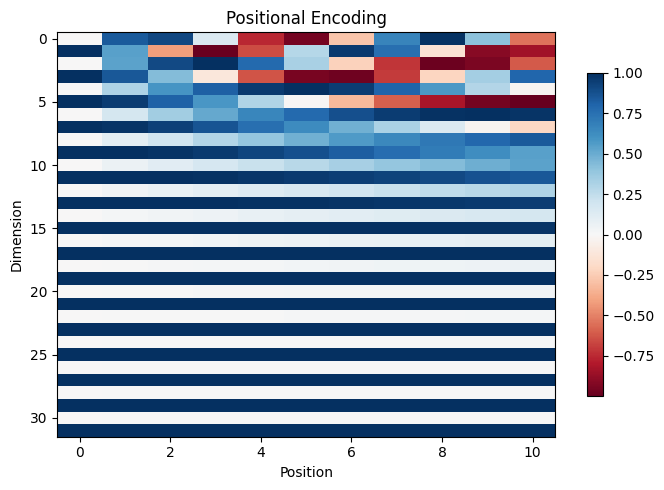

Training: Without PE
Training: With PE


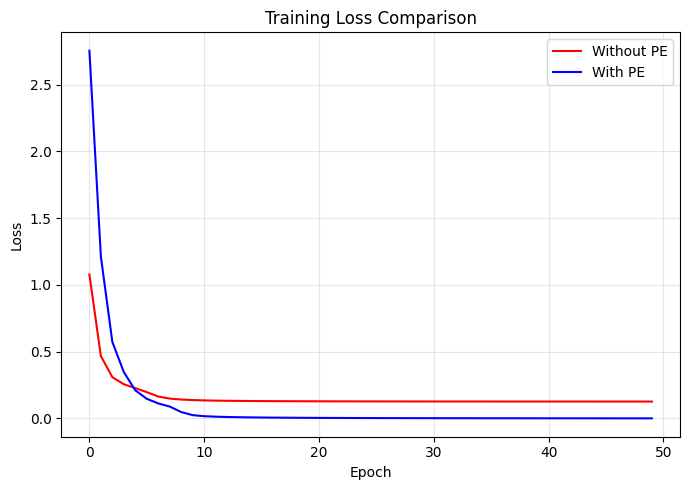

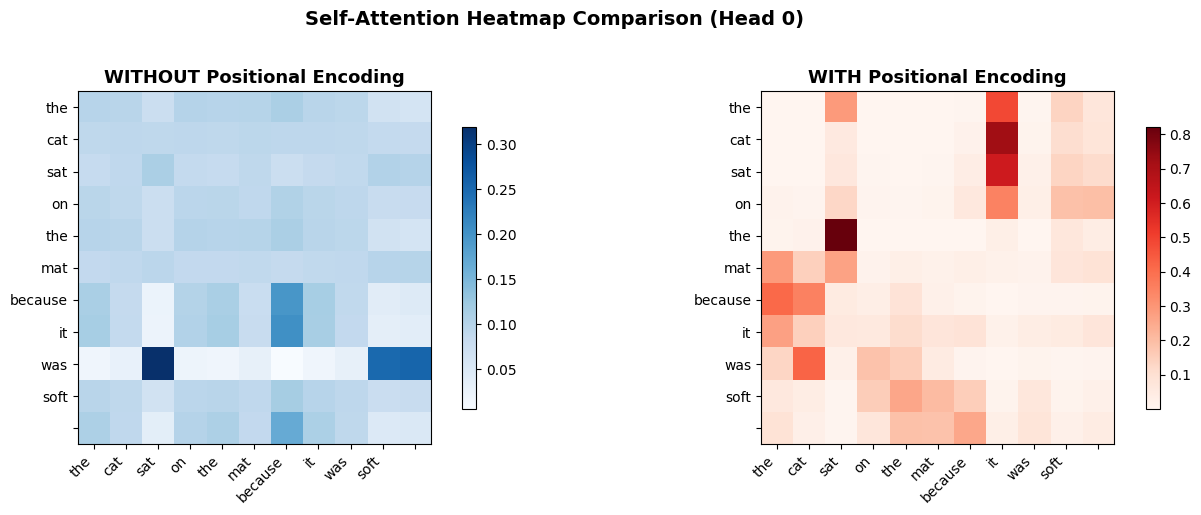

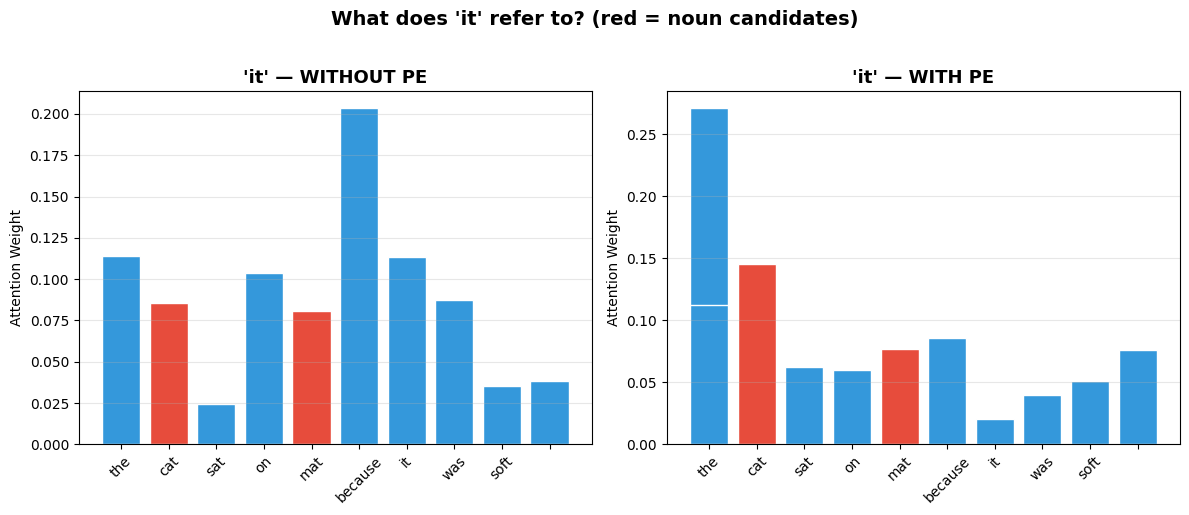

In [1]:
# ========================================================
# Week 14 : Self Attention + Positional Encoding
# Comparison with Week 14 + Temperature Generation
# ========================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

# =========================================
# 1. Toy Data
# =========================================
sentences = [
    "the cat sat on the mat because it was soft",
    "the cat sat on the mat because it was tired",
    "the dog ran to the park because it was excited",
    "the dog ran to the park because it was open",
    "the bird flew to the tree because it was tall",
    "the bird flew to the tree because it was hungry",
] * 300

SEQ_LEN = 12
d_model = 32
num_heads = 2
EPOCHS = 50

vectorizer = tf.keras.layers.TextVectorization(
    output_mode="int", output_sequence_length=SEQ_LEN)
vectorizer.adapt(sentences)
vocab = vectorizer.get_vocabulary()
vocab_size = len(vocab)

dataset = tf.data.Dataset.from_tensor_slices(sentences)
def make_lm_pair(text):
    tokens = vectorizer(text)
    return tokens[:-1], tokens[1:]
dataset = dataset.map(make_lm_pair).batch(64)

# =========================================
# 2. Positional Encoding
# =========================================
def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    dim = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dim // 2)) / d_model)
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

# --- Visualize PE ---
pe = get_positional_encoding(SEQ_LEN - 1, d_model)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pe[0].numpy().T, aspect='auto', cmap='RdBu')
ax.set(title='Positional Encoding', xlabel='Position', ylabel='Dimension')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

# =========================================
# 3. Two Models — Without PE / With PE
# =========================================
class TransformerNoPE(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.norm = tf.keras.layers.LayerNormalization()
        self.dense = tf.keras.layers.Dense(vocab_size)
    def call(self, x, return_attention=False):
        x = self.embedding(x)
        attn_out, attn_scores = self.mha(x, x, x, return_attention_scores=True)
        x = self.norm(x + attn_out)
        logits = self.dense(x)
        return (logits, attn_scores) if return_attention else logits

class TransformerWithPE(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pe = get_positional_encoding(SEQ_LEN, d_model)
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.norm = tf.keras.layers.LayerNormalization()
        self.dense = tf.keras.layers.Dense(vocab_size)
    def call(self, x, return_attention=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        attn_out, attn_scores = self.mha(x, x, x, return_attention_scores=True)
        x = self.norm(x + attn_out)
        logits = self.dense(x)
        return (logits, attn_scores) if return_attention else logits

# =========================================
# 4. Train Both
# =========================================
model_no_pe = TransformerNoPE()
model_no_pe.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer="adam")

model_pe = TransformerWithPE()
model_pe.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer="adam")

print("Training: Without PE")
h1 = model_no_pe.fit(dataset, epochs=EPOCHS, verbose=0)
print("Training: With PE")
h2 = model_pe.fit(dataset, epochs=EPOCHS, verbose=0)

# --- Loss Comparison ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(h1.history['loss'], 'r-', label='Without PE')
ax.plot(h2.history['loss'], 'b-', label='With PE')
ax.set(title='Training Loss Comparison', xlabel='Epoch', ylabel='Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# =========================================
# 5. Attention Comparison (Without PE vs With PE)
# =========================================
sample_tokens = vectorizer([sentences[0]])[:, :-1]
words = [vocab[i] for i in sample_tokens.numpy()[0]]

_, attn_no_pe = model_no_pe(sample_tokens, return_attention=True)
_, attn_pe = model_pe(sample_tokens, return_attention=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
im1 = ax1.imshow(attn_no_pe[0, 0].numpy(), cmap='Blues')
ax1.set_xticks(range(len(words))); ax1.set_xticklabels(words, rotation=45, ha='right')
ax1.set_yticks(range(len(words))); ax1.set_yticklabels(words)
ax1.set_title('WITHOUT Positional Encoding', fontsize=13, fontweight='bold')
fig.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(attn_pe[0, 0].numpy(), cmap='Reds')
ax2.set_xticks(range(len(words))); ax2.set_xticklabels(words, rotation=45, ha='right')
ax2.set_yticks(range(len(words))); ax2.set_yticklabels(words)
ax2.set_title('WITH Positional Encoding', fontsize=13, fontweight='bold')
fig.colorbar(im2, ax=ax2, shrink=0.8)

fig.suptitle('Self-Attention Heatmap Comparison (Head 0)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# --- "it" Row Comparison ---
it_idx = words.index("it")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

scores_no = attn_no_pe[0, 0, it_idx].numpy()
scores_pe = attn_pe[0, 0, it_idx].numpy()
nouns = ['cat','dog','bird','mat','park','tree']
colors = ['#e74c3c' if w in nouns else '#3498db' for w in words]

ax1.bar(words, scores_no, color=colors, edgecolor='white')
ax1.set_title("'it' — WITHOUT PE", fontsize=13, fontweight='bold')
ax1.set_ylabel('Attention Weight'); ax1.tick_params(axis='x', rotation=45); ax1.grid(axis='y', alpha=0.3)

ax2.bar(words, scores_pe, color=colors, edgecolor='white')
ax2.set_title("'it' — WITH PE", fontsize=13, fontweight='bold')
ax2.set_ylabel('Attention Weight'); ax2.tick_params(axis='x', rotation=45); ax2.grid(axis='y', alpha=0.3)

fig.suptitle("What does 'it' refer to? (red = noun candidates)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
